# Task 1 — Equity research pipeline

Prices → indicators (no TA-Lib) → news → LLM signal → HTML brief.

**Env:** local uses `.env`. Colab uses Secrets (key icon). `src/config.py` selects the source.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

# After you create the GitHub repo, put the HTTPS clone URL here.
REPO_URL = os.environ.get(
    "FINANCIAL_AI_REPO",
    "https://github.com/lavanblavan/Financial_AI.git",
)

def ensure_project() -> Path:
    if IN_COLAB:
        root = Path("/content/Financial_AI")
        if not (root / "src/config.py").exists():
            subprocess.run(["git", "clone", REPO_URL, str(root)], check=True)
        else:
            subprocess.run(["git", "-C", str(root), "pull", "--ff-only"], check=False)
        os.chdir(root)
    else:
        root = Path.cwd().resolve()
        if not (root / "src/config.py").exists():
            raise FileNotFoundError("Run this notebook from the repo root so src/ is visible.")

    req = root / "requirements.txt"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(req)], check=True)
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    return root

ROOT = ensure_project()
print("project root:", ROOT)
print("runtime:", "colab" if IN_COLAB else "local")

project root: /content/Financial_AI
runtime: colab


In [2]:
from src.config import describe_env, load_settings, missing_key_help

settings = load_settings()
print(describe_env(settings))
if not settings.llm_ready:
    print(missing_key_help(settings))

{'runtime': 'colab', 'secret_source': 'colab-secrets', 'ticker': 'AAPL', 'lookback': '2y', 'llm_provider': 'groq', 'llm_key_present': 'yes', 'groq_key_shape': 'gsk_*', 'groq_secret_status': 'present'}


In [3]:
from src.data import fetch_prices

prices = fetch_prices(settings.ticker, period=settings.lookback)
prices.tail()

,Open,High,Low,Close,Volume
Date,,,,,
2026-09-02,326.869995,328.399994,323.529999,324.959991,33776400
2026-09-03,324.869995,330.809998,324.109985,328.209991,37225800
2026-09-04,328.309998,328.929993,317.859985,319.970001,39606900
2026-09-08,317.100006,320.700012,314.899994,316.220001,35477100
2026-09-09,315.489990,319.149994,309.899994,315.339996,65640000


In [4]:
from src.indicators import add_indicators, latest_snapshot

df = add_indicators(prices)
snapshot = latest_snapshot(df)
display(df[["Close", "sma_50", "sma_200", "rsi_14", "macd", "macd_hist"]].tail())
snapshot

,Close,sma_50,sma_200,rsi_14,macd,macd_hist
Date,,,,,,
2026-09-02,324.959991,313.378975,282.890148,60.954474,1.951511,1.751697
2026-09-03,328.209991,314.086626,283.172845,63.479375,2.724499,2.019748
2026-09-04,319.970001,314.987768,283.439025,53.953206,2.641747,1.549596
2026-09-08,316.220001,315.641459,283.686555,50.256878,2.247662,0.924409
2026-09-09,315.339996,316.318314,283.924100,49.401551,1.843091,0.415871


{'date': '2026-09-09',
 'close': 315.3399963378906,
 'sma_50': 316.31831420898436,
 'sma_200': 283.9241004180908,
 'sma_cross': 'bullish',
 'sma_cross_flipped': False,
 'rsi_14': 49.40155103206529,
 'macd': 1.8430912848782555,
 'macd_signal': 1.427220266140125,
 'macd_hist': 0.4158710187381305,
 'bb_upper': 327.9350811844407,
 'bb_mid': 314.0594985961914,
 'bb_lower': 300.1839160079421,
 'bb_position': 'mid_band',
 'momentum_bias': 'bullish'}

## Indicator charts

Seaborn draws one static panel per indicator. Plotly below is interactive: hover, zoom, pan, and a range slider. Seaborn cannot do that by itself.

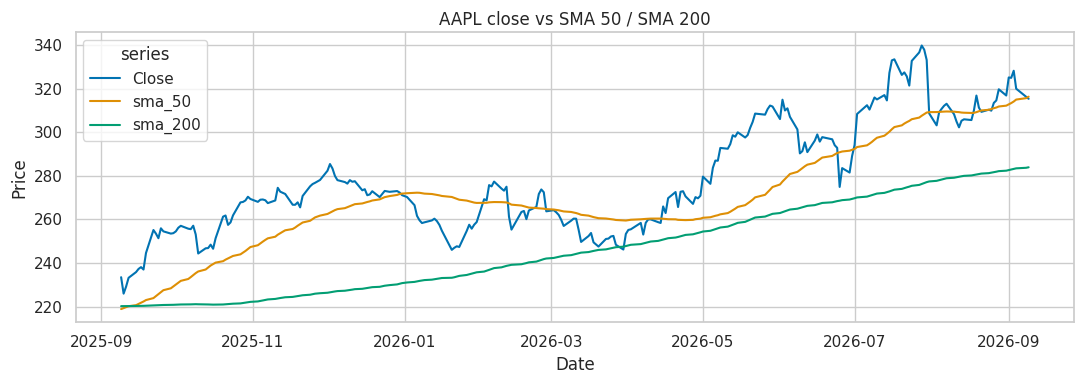

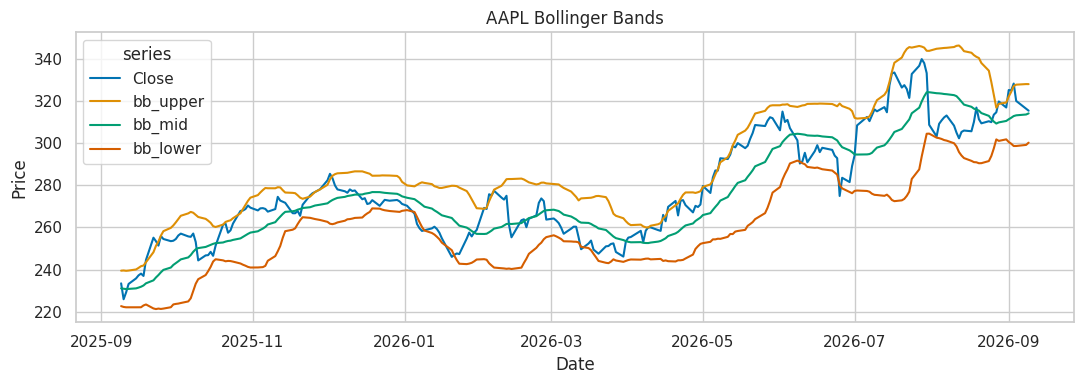

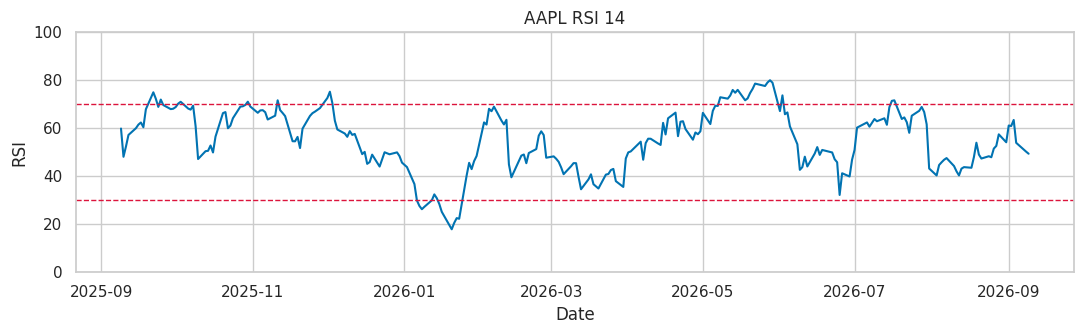

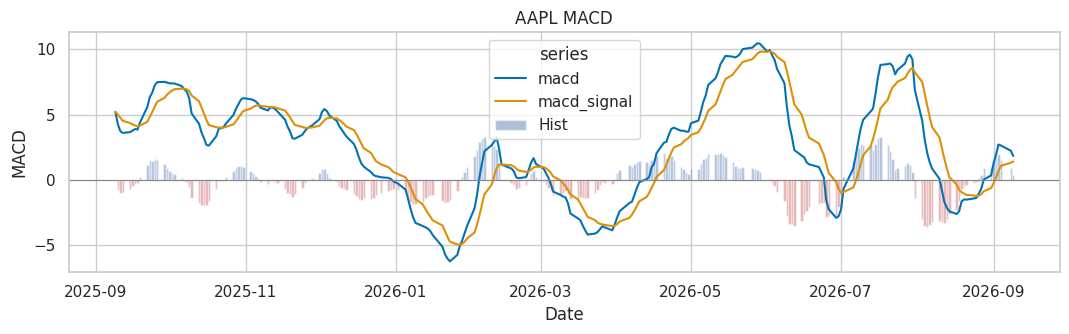

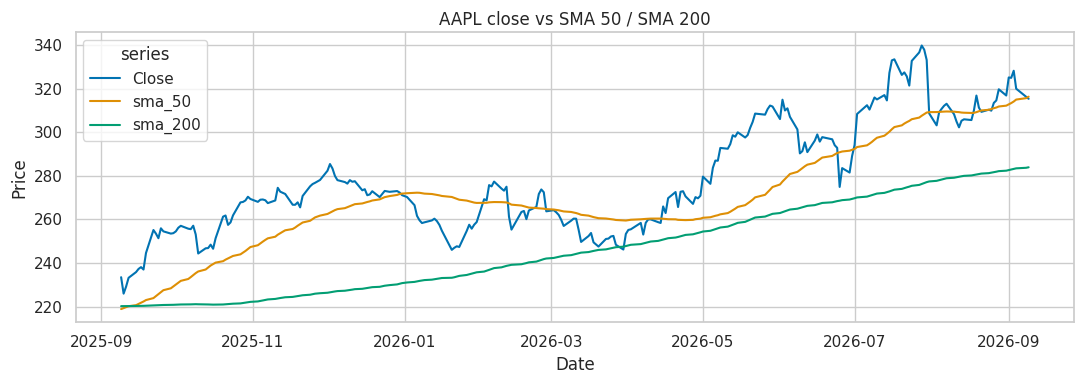

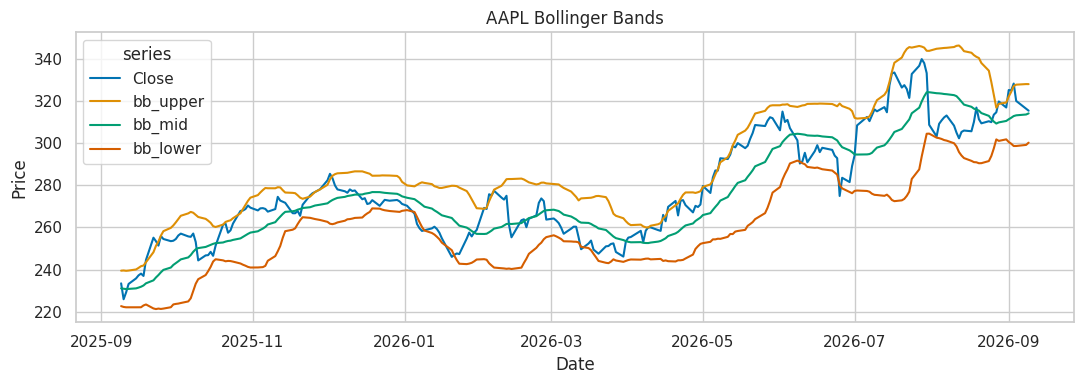

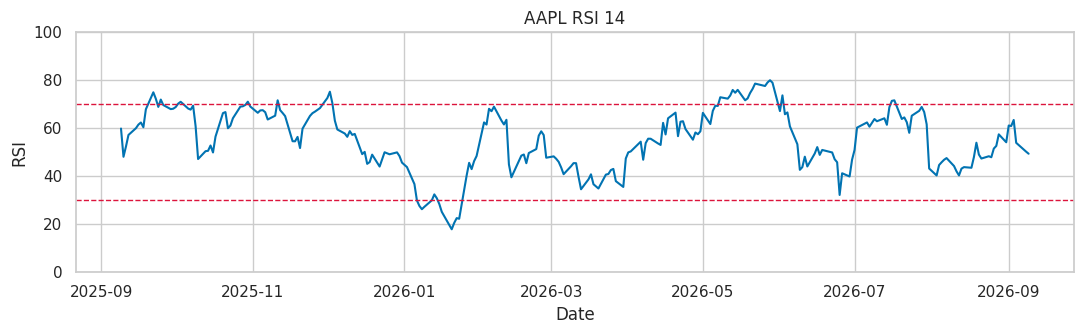

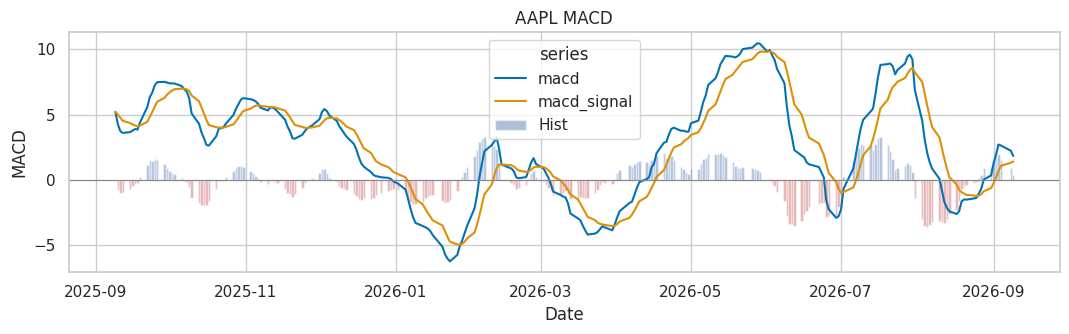

In [5]:
from src.plots import plot_all_seaborn, plot_interactive

for fig in plot_all_seaborn(df, ticker=settings.ticker):
    display(fig)

In [6]:
interactive = plot_interactive(df, ticker=settings.ticker)
interactive.show()

In [7]:
from src.news import fetch_news

headlines = fetch_news(settings.ticker, min_items=10)
print(f"{len(headlines)} headlines")
headlines

10 headlines


[{'title': "Why hardware will attract buyers to Apple's new lineup over AI features",
  'publisher': 'Yahoo Finance Video',
  'date': '2026-09-10T19:29',
  'source': 'yfinance'},
 {'title': "Apple's iPhone leasing program: How it works, what to consider as prices increase",
  'publisher': 'Yahoo Personal Finance',
  'date': '2026-07-31T14:31',
  'source': 'yfinance'},
 {'title': 'Apple iPhone Duo has 2 problems: Small hands and next-gen expectations',
  'publisher': 'Yahoo Finance',
  'date': '2026-09-10T11:11',
  'source': 'yfinance'},
 {'title': 'Apple launches iPhone 18 Pro and iPhone 18 Pro Max',
  'publisher': 'Yahoo Finance',
  'date': '2026-09-09T17:52',
  'source': 'yfinance'},
 {'title': 'Dow Jones Futures, Oracle Jumps After Oil Prices, Yields Surge; CPI Inflation Due',
  'publisher': "Investor's Business Daily",
  'date': '2026-09-11T01:07',
  'source': 'yfinance'},
 {'title': 'Dell enters the S&P 100 index after monstrous three-year rally',
  'publisher': 'TheStreet',
  'da

In [8]:
from src.signal import GroqAPIError, LLMNotConfiguredError, build_signal

try:
    result = build_signal(snapshot, headlines, settings, settings.ticker)
except (LLMNotConfiguredError, GroqAPIError) as exc:
    result = {
        "signal": "HOLD",
        "confidence": 0.0,
        "horizon": "n/a",
        "rationale": str(exc),
        "bull_case": "",
        "bear_case": "",
        "risks": ["LLM key not configured"],
    }
result

{'signal': 'BUY',
 'confidence': 0.75,
 'horizon': '1-4 weeks',
 'rationale': 'Apple’s price sits just below the 50‑day SMA but well above the 200‑day SMA, and the bullish SMA cross signals a short‑term uptrend. The MACD and its histogram are positive, RSI is neutral at 49.4, and momentum bias is bullish, all confirming technical strength. Recent headlines highlight the launch of the iPhone 18 Pro series and strong expectations for the iPhone Duo, with analysts predicting it will be a top seller despite its high price. Hardware focus is expected to drive demand, and the positive media coverage suggests a favorable reception. Combined, these signals point to a moderate‑to‑strong conviction for a short‑term rally.',
 'bull_case': 'Apple’s latest iPhone 18 Pro and Pro Max launch is expected to generate robust demand, especially as the company emphasizes hardware over AI features, appealing to core customers. The high‑margin premium pricing and strong brand loyalty should support revenue g

wrote /content/Financial_AI/outputs/AAPL_brief.html



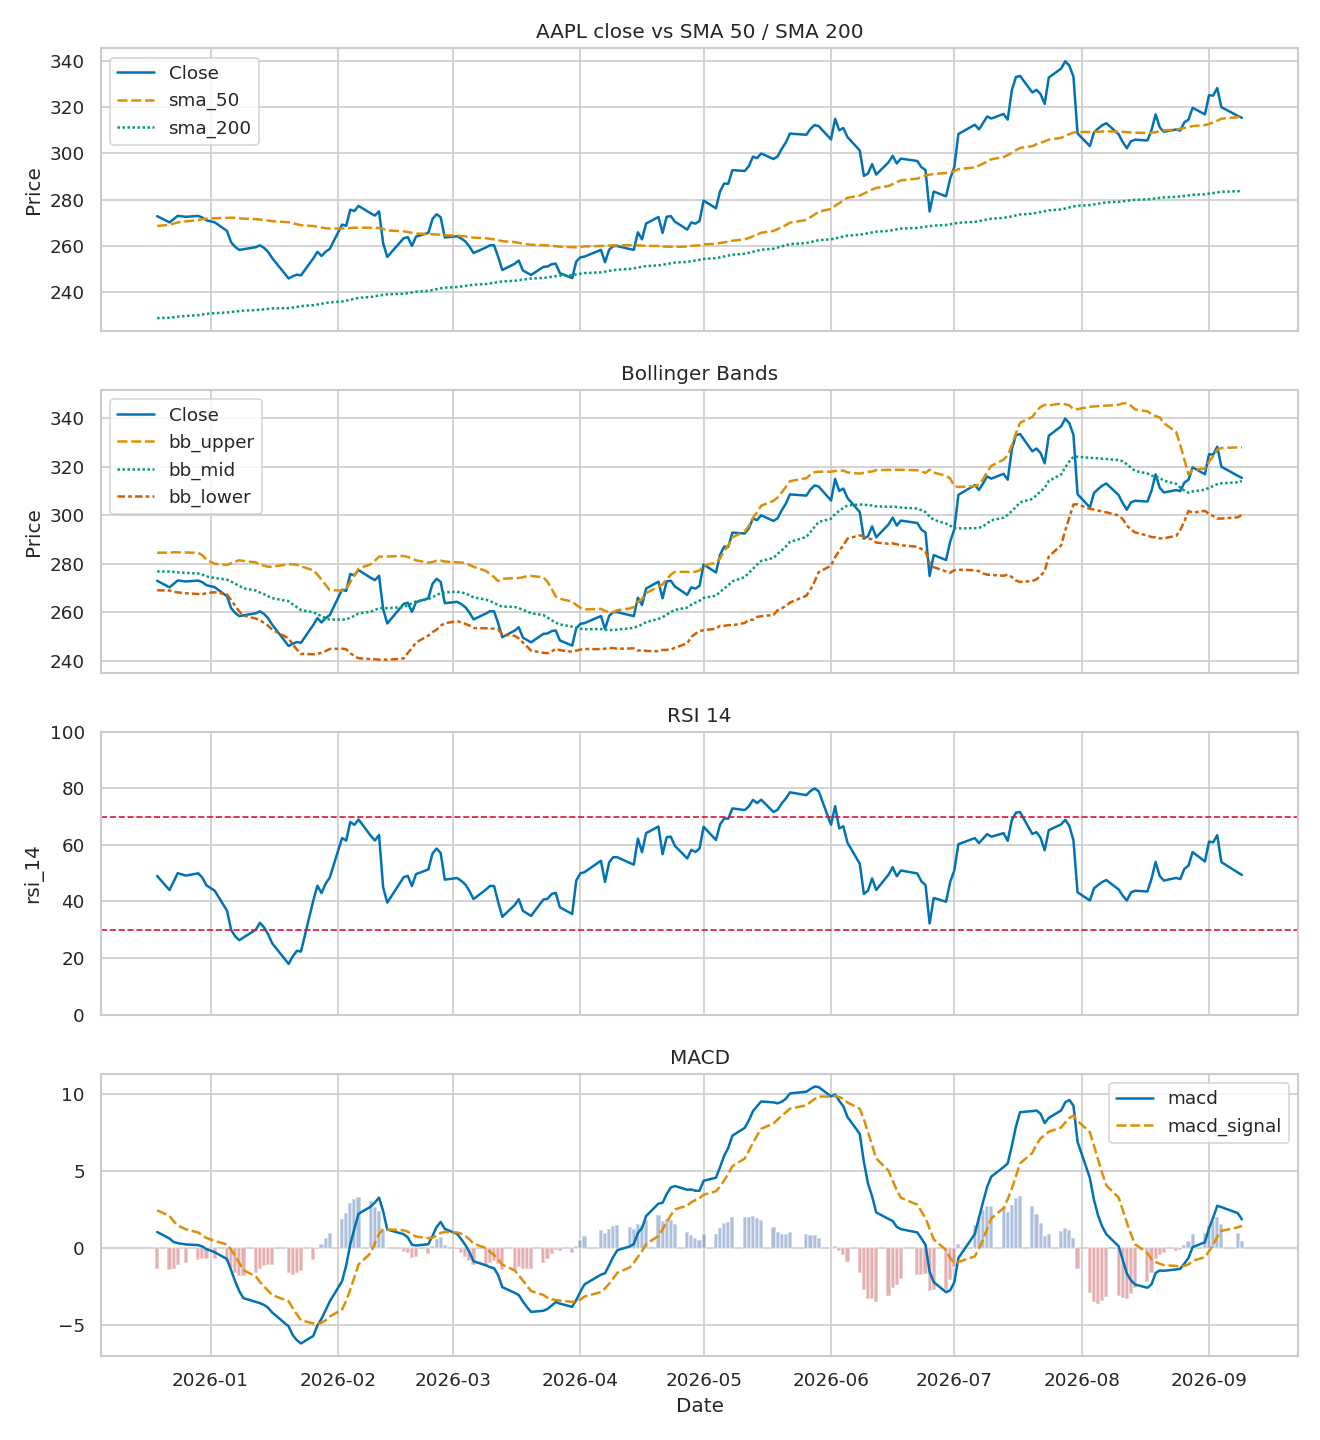

In [9]:
from IPython.display import HTML, display
from src.report import render_brief

brief_path = render_brief(settings.ticker, df, snapshot, headlines, result)
print("wrote", brief_path)
display(HTML(brief_path.read_text(encoding="utf-8")))

## Evaluation

Three checks, in this order:

1. **Formulas** — `pytest` already covers SMA, Wilder RSI bounds, MACD, Bollinger `ddof=0`.
2. **Walk-forward of the technical rule** — at each close, the momentum rule is BUY / HOLD / SELL. We then look at the *next* 5 / 10 / 20 day return. No look-ahead: signal at `t`, return from `t` to `t+h`. Last 126 days are held out so we do not only quote the in-sample window.
3. **Live LLM** — schema, and whether today's LLM signal agrees with today's rule. This does **not** prove the LLM has alpha. Historical news + LLM backtests would leak or need a dated news archive we do not have.

If BUY days do not earn more than SELL days on the holdout, the LLM is reasoning over a weak heuristic.

In [10]:
from src.evaluate import (
    add_forward_returns,
    evaluate_llm_output,
    holdout_split,
    strategy_equity,
    strategy_stats,
    walk_forward_table,
)
from src.evaluate import (
    add_forward_returns,
    evaluate_llm_output,
    holdout_split,
    strategy_equity,
    strategy_stats,
    walk_forward_table,
)

scored = add_forward_returns(df)
in_sample, holdout = holdout_split(scored, holdout_bars=126)

print("In-sample (earlier history)")
display(walk_forward_table(in_sample, horizon=10))
print("Holdout (last ~6 months)")
display(walk_forward_table(holdout, horizon=10))

equity = strategy_equity(holdout)
stats = strategy_stats(equity)
print(stats)

llm_eval = evaluate_llm_output(snapshot, result)
print("Live LLM checks:", llm_eval)

scored = add_forward_returns(df)
in_sample, holdout = holdout_split(scored, holdout_bars=126)

print("In-sample (earlier history)")
display(walk_forward_table(in_sample, horizon=10))
print("Holdout (last ~6 months)")
display(walk_forward_table(holdout, horizon=10))

equity = strategy_equity(holdout)
stats = strategy_stats(equity)
print(stats)

llm_eval = evaluate_llm_output(snapshot, result)
print("Live LLM checks:", llm_eval)

In-sample (earlier history)


,signal,n,mean_fwd_return,hit_rate
0,BUY,34,-0.011537,0.323529
1,HOLD,133,0.011083,NaN
2,SELL,8,0.122178,0.000000


Holdout (last ~6 months)


,signal,n,mean_fwd_return,hit_rate
0,BUY,46,0.028727,0.782609
1,HOLD,70,0.017555,NaN
2,SELL,0,NaN,NaN


{'strategy_total_return': 0.22201684432258917, 'buy_hold_total_return': 0.21123706745682047, 'strategy_sharpe': 2.13799309295778, 'buy_hold_sharpe': 1.5337846344220352, 'excess_return': 0.010779776865768698}
Live LLM checks: {'schema_ok': True, 'signal': 'BUY', 'rule_signal': 'BUY', 'agrees_with_rule': True, 'overbought_buy_conflict': False, 'has_rationale': True, 'n_risks': 3}
In-sample (earlier history)


,signal,n,mean_fwd_return,hit_rate
0,BUY,34,-0.011537,0.323529
1,HOLD,133,0.011083,NaN
2,SELL,8,0.122178,0.000000


Holdout (last ~6 months)


,signal,n,mean_fwd_return,hit_rate
0,BUY,46,0.028727,0.782609
1,HOLD,70,0.017555,NaN
2,SELL,0,NaN,NaN


{'strategy_total_return': 0.22201684432258917, 'buy_hold_total_return': 0.21123706745682047, 'strategy_sharpe': 2.13799309295778, 'buy_hold_sharpe': 1.5337846344220352, 'excess_return': 0.010779776865768698}
Live LLM checks: {'schema_ok': True, 'signal': 'BUY', 'rule_signal': 'BUY', 'agrees_with_rule': True, 'overbought_buy_conflict': False, 'has_rationale': True, 'n_risks': 3}


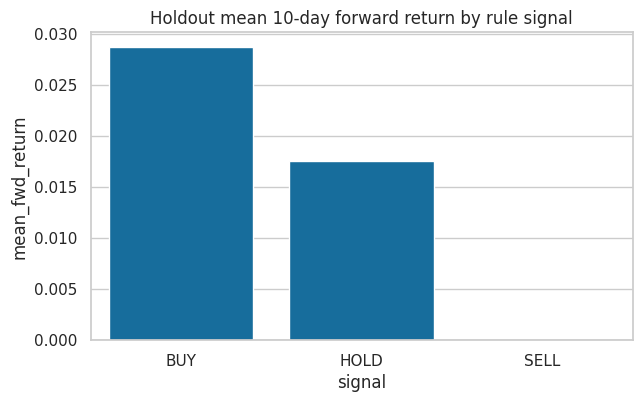

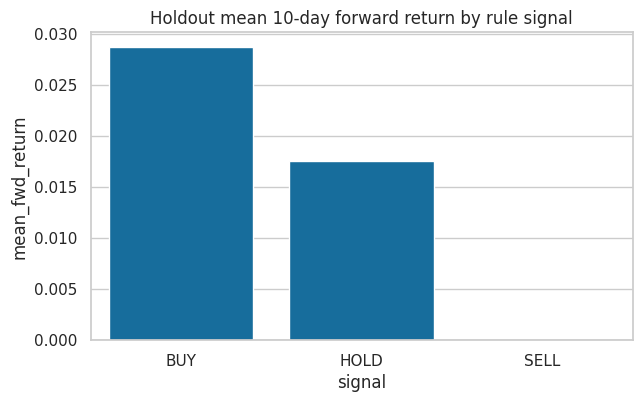

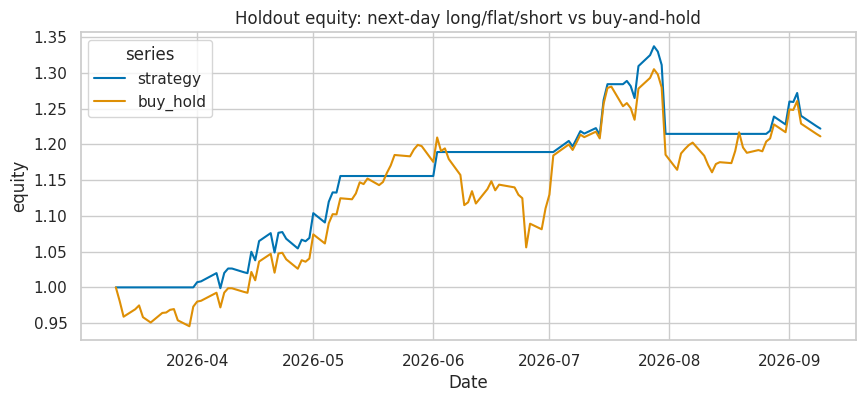

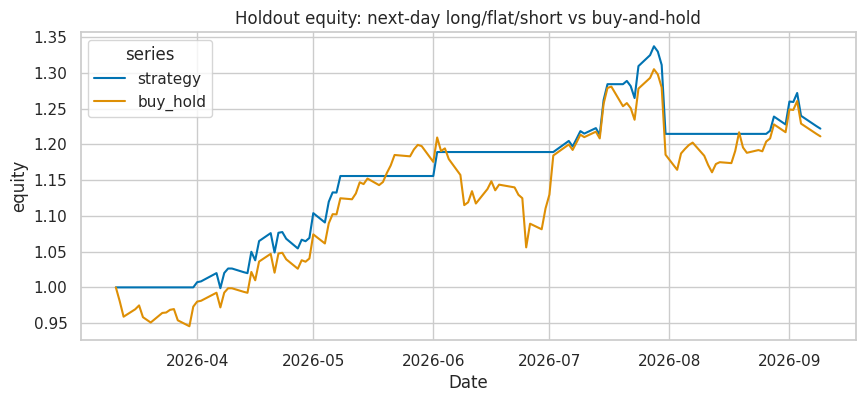

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

table = walk_forward_table(holdout, horizon=10)
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=table, x="signal", y="mean_fwd_return", ax=ax)
ax.axhline(0, color="#888", linewidth=0.8)
ax.set_title("Holdout mean 10-day forward return by rule signal")
display(fig)
plt.close(fig)

import seaborn as sns
import matplotlib.pyplot as plt

table = walk_forward_table(holdout, horizon=10)
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=table, x="signal", y="mean_fwd_return", ax=ax)
ax.axhline(0, color="#888", linewidth=0.8)
ax.set_title("Holdout mean 10-day forward return by rule signal")
display(fig)
plt.close(fig)

eq_plot = equity[["strategy", "buy_hold"]].rename_axis("Date")
eq_long = eq_plot.reset_index().melt(id_vars="Date", var_name="series", value_name="equity")
fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=eq_long, x="Date", y="equity", hue="series", ax=ax)
ax.set_title("Holdout equity: next-day long/flat/short vs buy-and-hold")
display(fig)
plt.close(fig)
fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=eq_long, x="Date", y="equity", hue="series", ax=ax)
ax.set_title("Holdout equity: next-day long/flat/short vs buy-and-hold")
display(fig)
plt.close(fig)

## Historical replay (the evaluation you asked for)

No toy prices. We freeze **May 2026** only (real AAPL month):

1. Freeze the calendar on that day  
2. Compute indicators using **only closes up to that day**  
3. Load **May 2026** Apple headlines from GDELT (dated news, one download for the month)  
4. Ask the same BUY / HOLD / SELL decision (LLM if the key works, otherwise the rule)  
5. Look at the **real** next 10 trading days of AAPL  

**Match** = BUY and the stock went up, or SELL and it went down. HOLD is not scored as a hit (it is not a directional bet).

GDELT is still not Bloomberg, but it is dated (we saw May 2026 Apple articles). Wait 5+ seconds if you re-run; the API rate-limits.

In [12]:
from IPython.display import HTML, display
from src.replay import render_replay_report, replay_history, replay_summary

# step=21 ≈ one decision per month. use_llm=True uses Groq; set False to score the rule only.
replay = replay_history(
    prices,
    settings.ticker,
    settings=settings,
    start="2026-05-01",
    end="2026-05-31",
    step=2,
    horizon=10,
    use_llm=True,
)
summary = replay_summary(replay)
display(replay[["date", "signal", "rule_signal", "n_headlines", "fwd_return", "actual_move", "match"]])
print(summary)

replay_path = render_replay_report(settings.ticker, replay, summary, horizon=10)
print("wrote", replay_path)
display(HTML(open(replay_path, encoding="utf-8").read()))

,date,signal,rule_signal,n_headlines,fwd_return,actual_move,match
0,2025-07-31,HOLD,SELL,8,0.122726,UP,False
1,2025-08-29,HOLD,HOLD,8,0.019643,UP,False
2,2025-09-30,BUY,BUY,8,-0.026941,DOWN,False
3,2025-10-29,BUY,BUY,8,0.014961,UP,True
4,2025-11-28,HOLD,BUY,8,-0.002044,DOWN,False
5,2025-12-30,HOLD,HOLD,8,-0.048044,DOWN,False
6,2026-01-30,BUY,BUY,8,-0.013337,DOWN,False
7,2026-03-03,HOLD,HOLD,8,-0.036095,DOWN,False
8,2026-04-01,BUY,BUY,8,0.030395,UP,True
9,2026-05-01,BUY,BUY,8,0.072702,UP,True


{'n_dates': 13, 'n_buy': 6, 'n_sell': 0, 'n_hold': 7, 'n_directional': 6, 'directional_accuracy': 0.6666666666666666, 'mean_return_after_buy': 0.026523321019434665, 'mean_return_after_sell': None, 'n_with_headlines': 13}
wrote /content/Financial_AI/outputs/AAPL_replay.html


Date,Close,Our call,Rule only,News,Next 10d,Actual,Match,Headline
2025-07-31,206.57,HOLD,SELL,8,12.27%,UP,No,"As Apple Teases iOS 26, Is AAPL Stock a Buy, Sell, or Hold? - Yahoo Finance"
2025-08-29,231.29,HOLD,HOLD,8,1.96%,UP,No,"AAPL Stock Price Prediction: Where Apple Could Be by 2025, 2026, and 2030 - Yahoo Finance"
2025-09-30,253.69,BUY,BUY,8,-2.69%,DOWN,No,Apple (AAPL) Stock Target Lifted to $280 as Analysts See Upside in iPhone 17 Cycle - Yaho…
2025-10-29,268.71,BUY,BUY,8,1.50%,UP,Yes,Apple Stock Hits New Record on Report of Strong iPhone Sales - WSJ
2025-11-28,278.09,HOLD,BUY,8,-0.20%,DOWN,No,Where Will Apple Stock Be in 5 Years? - Yahoo Finance
2025-12-30,272.34,HOLD,HOLD,8,-4.80%,DOWN,No,Apple Stock (AAPL) Opinions on AI Model Release and Regulatory Fine | AAPL Stock News - Q…
2026-01-30,258.78,BUY,BUY,8,-1.33%,DOWN,No,"Ahead of Earnings, Is Apple Stock a Buy, a Sell, or Fairly Valued? - Morningstar"
2026-03-03,263.28,HOLD,HOLD,8,-3.61%,DOWN,No,Apple Stock: Is AAPL Underperforming the Technology Sector? - Yahoo Finance
2026-04-01,255.17,BUY,BUY,8,3.04%,UP,Yes,Morgan Stanley Is Doubling Down on Apple Stock Thanks to Still-High iPhone Demand. Should…
2026-05-01,279.64,BUY,BUY,8,7.27%,UP,Yes,"Apple (AAPL) Stock Trades Up, Here Is Why - Yahoo Finance"
